# Diseño SFV — Edificio TABAREC División 3

**Proyecto:** SFV_TABAREC_DIV3  
**Inicio:** 2026-06-22  
**Fuente inicial:** Recibo CEDENAR — Febrero 2026 (medidor HOL-100504639)

Diferencia vs proyecto zonas comunes: **se resta la carga del ascensor** (no se agrega).

## Registro de avance

| # | Etapa | Estado | Notas |
|---|-------|--------|-------|
| 0 | Datos del recibo | ✅ | CEDENAR Feb/2026 — Div 3 |
| 1 | Perfil de consumo | ✅ | Histórico del recibo |
| 1b | Ajuste ascensor | ✅ | Se **resta** carga del ascensor |
| 1d | Costo ascensor vs sin ascensor | ✅ | Desglose energía y factura |
| 2 | Factura cero + equipos | ✅ | Huawei SUN2000 + 710 Wp |

---
## Etapa 0 — Datos del recibo CEDENAR

| Campo | Valor |
|-------|-------|
| Empresa | CEDENAR S.A. E.S.P. |
| Titular | Luis Carlos Millán Tabares |
| Dirección | Cra 28 Calle 17-39, **Div 3**, Edif. TABAREC |
| Ciudad | Pasto, Nariño, Colombia |
| Tipo de uso | No residencial — Comercial |
| Medidor | **HOL-100504639** |
| Período facturado | 16/01/2026 – 14/02/2026 |
| Consumo del período | **1 580 kWh** |
| Costo unitario (CUv) | **$883,72 COP/kWh** |
| Valor energía activa | $1 396 277,60 |
| Contribución (20%) | $279 255,52 |
| Alumbrado público | $214 802,00 |
| **Total a pagar** | **$1 890 340 COP** |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

recibo = {
    "empresa": "CEDENAR S.A. E.S.P.",
    "titular": "Luis Carlos Millán Tabares",
    "direccion": "Cra 28 Calle 17-39, Div 3, Edif. TABAREC",
    "ciudad": "Pasto",
    "departamento": "Nariño",
    "tipo_uso": "No residencial — Comercial",
    "medidor": "HOL-100504639",
    "mes_facturado": "Febrero 2026",
    "periodo_inicio": "2026-01-16",
    "periodo_fin": "2026-02-14",
    "dias_periodo": 29,
    "consumo_kwh": 1580,
    "cuv_cop_kwh": 883.72,
    "valor_energia_cop": 1_396_277.60,
    "contribucion_cop": 279_255.52,
    "alumbrado_publico_cop": 214_802.00,
    "total_pagar_cop": 1_890_340,
}

print(f"Medidor: {recibo['medidor']}")
print(f"Consumo período: {recibo['consumo_kwh']:,} kWh")
print(f"Total a pagar: ${recibo['total_pagar_cop']:,} COP")

Medidor: HOL-100504639
Consumo período: 1,580 kWh
Total a pagar: $1,890,340 COP


---
## Etapa 1 — Perfil de consumo (recibo)

In [2]:
# Consumo mensual (kWh) — gráfico del recibo (7 meses visibles + promedio factura)
consumo_mensual_recibo = {
    "Ago": 1521, "Sep": 1657, "Oct": 1572, "Nov": 1594,
    "Dic": 1591, "Ene": 1555, "Feb": 1580,
}

df_recibo = pd.DataFrame({
    "mes": list(consumo_mensual_recibo.keys()),
    "kwh_recibo": list(consumo_mensual_recibo.values()),
})

consumo_promedio_recibo = df_recibo["kwh_recibo"].mean()
consumo_anual_recibo = consumo_promedio_recibo * 12   # proyección anual desde promedio

print("=== Consumo según recibo (incluye ascensor) ===")
print(f"Promedio mensual:  {consumo_promedio_recibo:,.1f} kWh/mes")
print(f"Anual estimado:    {consumo_anual_recibo:,.0f} kWh/año")
print(f"Factura prom/mes:  ${recibo['total_pagar_cop'] / recibo['consumo_kwh'] * consumo_promedio_recibo:,.0f} COP")

=== Consumo según recibo (incluye ascensor) ===
Promedio mensual:  1,581.4 kWh/mes
Anual estimado:    18,977 kWh/año
Factura prom/mes:  $1,892,049 COP


---
## Etapa 1b — Ajuste: quitar carga del ascensor

El recibo actual **incluye** el ascensor. Para el diseño del SFV se modela su **retiro**.

| Parámetro | Valor |
|-----------|-------|
| Motor | 7,5 kW · 7 pisos · Lun–Sáb 7:00–18:00 |
| **Costo real ascensor** | **~$400 000 COP/mes** (dato usuario) |
| Estimación teórica | ~176 kWh/mes (referencia técnica) |

In [17]:
# --- Costo real del ascensor (dato usuario) ---
COSTO_ASCENSOR_MES_REAL = 400_000   # COP/mes — factura aproximada del ascensor

# Tarifa de referencia del recibo (costo total por kWh)
TARIFA_TOTAL_KWH = recibo["total_pagar_cop"] / recibo["consumo_kwh"]

# kWh equivalente del ascensor según lo que realmente se paga
KWH_ASCENSOR_MES = round(COSTO_ASCENSOR_MES_REAL / TARIFA_TOTAL_KWH, 1)
KWH_ASCENSOR_ANUAL = round(KWH_ASCENSOR_MES * 12, 0)

# Estimación teórica (referencia — motor 7.5 kW, 70 viajes/día)
KWH_ASCENSOR_TEORICO = 176.3

# Consumo de diseño = recibo − ascensor
df_consumo = df_recibo.copy()
df_consumo["kwh_ascensor"] = KWH_ASCENSOR_MES
df_consumo["kwh_diseno"] = df_consumo["kwh_recibo"] - df_consumo["kwh_ascensor"]

consumo_promedio_diseno = df_consumo["kwh_diseno"].mean()
consumo_anual_diseno = consumo_promedio_diseno * 12

print(f"Costo real ascensor:   ${COSTO_ASCENSOR_MES_REAL:,} COP/mes")
print(f"kWh equivalente:       {KWH_ASCENSOR_MES} kWh/mes  ({KWH_ASCENSOR_ANUAL:.0f} kWh/año)")
print(f"  (teórico motor 7.5kW: {KWH_ASCENSOR_TEORICO} kWh/mes — referencia)")
print(f"\n=== Consumo de diseño (SIN ascensor) ===")
print(f"Promedio mensual:      {consumo_promedio_diseno:,.1f} kWh/mes")
print(f"Anual estimado:        {consumo_anual_diseno:,.0f} kWh/año")
print(f"Reducción vs recibo:   -{KWH_ASCENSOR_MES/consumo_promedio_recibo*100:.1f} %")

Costo real ascensor:   $400,000 COP/mes
kWh equivalente:       334.3 kWh/mes  (4012 kWh/año)
  (teórico motor 7.5kW: 176.3 kWh/mes — referencia)

=== Consumo de diseño (SIN ascensor) ===
Promedio mensual:      1,247.1 kWh/mes
Anual estimado:        14,966 kWh/año
Reducción vs recibo:   -21.1 %


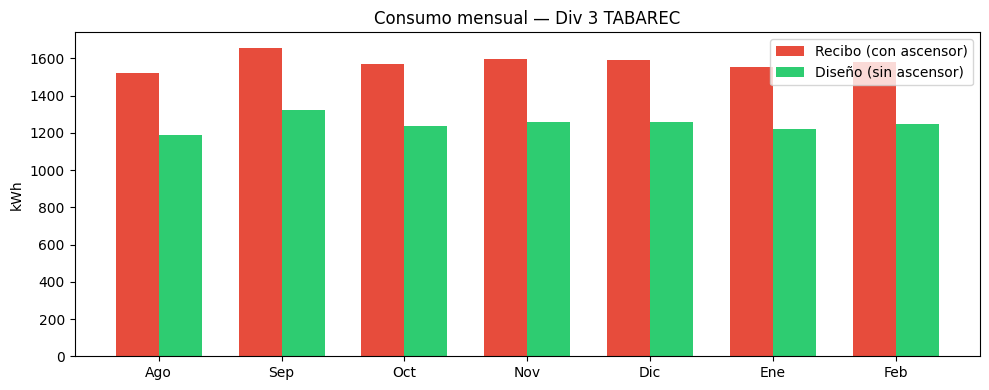

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(df_consumo))
w = 0.35
ax.bar([i - w/2 for i in x], df_consumo["kwh_recibo"], width=w, label="Recibo (con ascensor)", color="#e74c3c")
ax.bar([i + w/2 for i in x], df_consumo["kwh_diseno"], width=w, label="Diseño (sin ascensor)", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(df_consumo["mes"])
ax.set_ylabel("kWh")
ax.set_title("Consumo mensual — Div 3 TABAREC")
ax.legend()
plt.tight_layout()
plt.show()

---
## Etapa 1c — Factura mensual (recibo vs diseño sin ascensor)

In [5]:
CUV = recibo["cuv_cop_kwh"]
PCT_CONTRIBUCION = recibo["contribucion_cop"] / recibo["valor_energia_cop"]
ALUMBRADO_POR_KWH = recibo["alumbrado_publico_cop"] / recibo["consumo_kwh"]
COSTO_TOTAL_POR_KWH = CUV * (1 + PCT_CONTRIBUCION) + ALUMBRADO_POR_KWH

def calcular_factura(kwh):
    energia = kwh * CUV
    contribucion = energia * PCT_CONTRIBUCION
    alumbrado = kwh * ALUMBRADO_POR_KWH
    return {
        "energia_cop": round(energia, 0),
        "contribucion_cop": round(contribucion, 0),
        "alumbrado_cop": round(alumbrado, 0),
        "total_cop": round(energia + contribucion + alumbrado, 0),
    }

filas = []
for _, row in df_consumo.iterrows():
    f_recibo = calcular_factura(row["kwh_recibo"])
    f_diseno = calcular_factura(row["kwh_diseno"])
    filas.append({
        "mes": row["mes"],
        "kwh_recibo": row["kwh_recibo"],
        "kwh_diseno": round(row["kwh_diseno"], 0),
        "factura_recibo": f_recibo["total_cop"],
        "factura_diseno": f_diseno["total_cop"],
        "ahorro_ascensor": f_recibo["total_cop"] - f_diseno["total_cop"],
    })

df_factura = pd.DataFrame(filas)
prom_fact_recibo = df_factura["factura_recibo"].mean()
prom_fact_diseno = df_factura["factura_diseno"].mean()

print("=== Factura mensual promedio ===")
print(f"Con ascensor (recibo):   ${prom_fact_recibo:,.0f} COP/mes")
print(f"Sin ascensor (diseño):   ${prom_fact_diseno:,.0f} COP/mes")
print(f"Ahorro por quitar asc.:  ${prom_fact_recibo - prom_fact_diseno:,.0f} COP/mes")
print(f"\nCosto total estimado:   ${COSTO_TOTAL_POR_KWH:,.2f} /kWh")

=== Factura mensual promedio ===
Con ascensor (recibo):   $1,892,044 COP/mes
Sin ascensor (diseño):   $1,681,116 COP/mes
Ahorro por quitar asc.:  $210,928 COP/mes

Costo total estimado:   $1,196.41 /kWh


---
## Etapa 1d — ¿Cuánto se paga con ascensor vs sin ascensor?

Desglose del **costo del ascensor** y comparación de factura completa (energía + contribución + alumbrado público).

In [19]:
def desglose_factura(kwh):
    f = calcular_factura(kwh)
    f["kwh"] = kwh
    return f

# Costo del ascensor: dato real del usuario
costo_ascensor_mes = desglose_factura(KWH_ASCENSOR_MES)
# Ajustar al costo real reportado (por si hay redondeo)
costo_ascensor_mes["total_cop"] = COSTO_ASCENSOR_MES_REAL
# Recalcular proporciones del desglose según tarifa
costo_ascensor_mes["energia_cop"] = round(KWH_ASCENSOR_MES * CUV, 0)
costo_ascensor_mes["contribucion_cop"] = round(costo_ascensor_mes["energia_cop"] * PCT_CONTRIBUCION, 0)
costo_ascensor_mes["alumbrado_cop"] = round(KWH_ASCENSOR_MES * ALUMBRADO_POR_KWH, 0)

fact_con_asc_mes = desglose_factura(consumo_promedio_recibo)
fact_sin_asc_mes = desglose_factura(consumo_promedio_diseno)

comparacion = pd.DataFrame({
    "Concepto": ["kWh consumo", "Energía activa", "Contribución (20%)", "Alumbrado público", "TOTAL factura"],
    "Solo ascensor ($400K)": [
        f"{KWH_ASCENSOR_MES:.0f} kWh",
        f"${costo_ascensor_mes['energia_cop']:,.0f}",
        f"${costo_ascensor_mes['contribucion_cop']:,.0f}",
        f"${costo_ascensor_mes['alumbrado_cop']:,.0f}",
        f"${COSTO_ASCENSOR_MES_REAL:,.0f}",
    ],
    "Con ascensor (recibo)": [
        f"{consumo_promedio_recibo:,.0f} kWh",
        f"${fact_con_asc_mes['energia_cop']:,.0f}",
        f"${fact_con_asc_mes['contribucion_cop']:,.0f}",
        f"${fact_con_asc_mes['alumbrado_cop']:,.0f}",
        f"${fact_con_asc_mes['total_cop']:,.0f}",
    ],
    "Sin ascensor (diseño)": [
        f"{consumo_promedio_diseno:,.0f} kWh",
        f"${fact_sin_asc_mes['energia_cop']:,.0f}",
        f"${fact_sin_asc_mes['contribucion_cop']:,.0f}",
        f"${fact_sin_asc_mes['alumbrado_cop']:,.0f}",
        f"${fact_sin_asc_mes['total_cop']:,.0f}",
    ],
})

print("=" * 70)
print("COSTO DE ENERGÍA — DIV 3 TABAREC (promedio mensual)")
print("=" * 70)
print(comparacion.to_string(index=False))

print(f"\n{'—'*70}")
print("RESUMEN ANUAL")
print(f"{'—'*70}")
print(f"  Costo del ascensor:           ${COSTO_ASCENSOR_MES_REAL * 12:,.0f} COP/año  (${COSTO_ASCENSOR_MES_REAL:,}/mes)")
print(f"  Factura CON ascensor:         ${fact_con_asc_mes['total_cop'] * 12:,.0f} COP/año  (${fact_con_asc_mes['total_cop']:,.0f}/mes)")
print(f"  Factura SIN ascensor:         ${fact_sin_asc_mes['total_cop'] * 12:,.0f} COP/año  (${fact_sin_asc_mes['total_cop']:,.0f}/mes)")
print(f"  Ahorro al quitar ascensor:    ${(fact_con_asc_mes['total_cop'] - fact_sin_asc_mes['total_cop']) * 12:,.0f} COP/año")
print(f"  Ascensor = {COSTO_ASCENSOR_MES_REAL/fact_con_asc_mes['total_cop']*100:.1f} % de la factura actual")

COSTO DE ENERGÍA — DIV 3 TABAREC (promedio mensual)
          Concepto Solo ascensor ($400K) Con ascensor (recibo) Sin ascensor (diseño)
       kWh consumo               334 kWh             1,581 kWh             1,247 kWh
    Energía activa              $295,428            $1,397,540            $1,102,112
Contribución (20%)               $59,086              $279,508              $220,422
 Alumbrado público               $45,448              $214,996              $169,548
     TOTAL factura              $400,000            $1,892,044            $1,492,083

——————————————————————————————————————————————————————————————————————
RESUMEN ANUAL
——————————————————————————————————————————————————————————————————————
  Costo del ascensor:           $4,800,000 COP/año  ($400,000/mes)
  Factura CON ascensor:         $22,704,528 COP/año  ($1,892,044/mes)
  Factura SIN ascensor:         $17,904,996 COP/año  ($1,492,083/mes)
  Ahorro al quitar ascensor:    $4,799,532 COP/año
  Ascensor = 21.1 % de 

In [20]:
# Ejemplo Febrero 2026
kwh_feb_con = recibo["consumo_kwh"]
kwh_feb_sin = kwh_feb_con - KWH_ASCENSOR_MES

feb_con = desglose_factura(kwh_feb_con)
feb_sin = desglose_factura(kwh_feb_sin)

feb_tabla = pd.DataFrame({
    "Concepto": ["kWh", "Energía activa", "Contribución (20%)", "Alumbrado público", "TOTAL"],
    "Feb CON ascensor": [
        f"{kwh_feb_con:,} kWh",
        f"${feb_con['energia_cop']:,.0f}",
        f"${feb_con['contribucion_cop']:,.0f}",
        f"${feb_con['alumbrado_cop']:,.0f}",
        f"${recibo['total_pagar_cop']:,.0f}",
    ],
    "Feb SIN ascensor": [
        f"{kwh_feb_sin:,.0f} kWh",
        f"${feb_sin['energia_cop']:,.0f}",
        f"${feb_sin['contribucion_cop']:,.0f}",
        f"${feb_sin['alumbrado_cop']:,.0f}",
        f"${feb_sin['total_cop']:,.0f}",
    ],
    "Ascensor (~$400K)": [
        f"{KWH_ASCENSOR_MES:.0f} kWh",
        f"${costo_ascensor_mes['energia_cop']:,.0f}",
        f"${costo_ascensor_mes['contribucion_cop']:,.0f}",
        f"${costo_ascensor_mes['alumbrado_cop']:,.0f}",
        f"${COSTO_ASCENSOR_MES_REAL:,.0f}",
    ],
})

print("EJEMPLO — Factura Febrero 2026\n")
print(feb_tabla.to_string(index=False))
print(f"\nSin ascensor la factura de Feb bajaría de ${recibo['total_pagar_cop']:,} a ${feb_sin['total_cop']:,.0f} COP")

EJEMPLO — Factura Febrero 2026

          Concepto Feb CON ascensor Feb SIN ascensor Ascensor (~$400K)
               kWh        1,580 kWh        1,246 kWh           334 kWh
    Energía activa       $1,396,278       $1,100,850          $295,428
Contribución (20%)         $279,256         $220,170           $59,086
 Alumbrado público         $214,802         $169,354           $45,448
             TOTAL       $1,890,340       $1,490,374          $400,000

Sin ascensor la factura de Feb bajaría de $1,890,340 a $1,490,374 COP


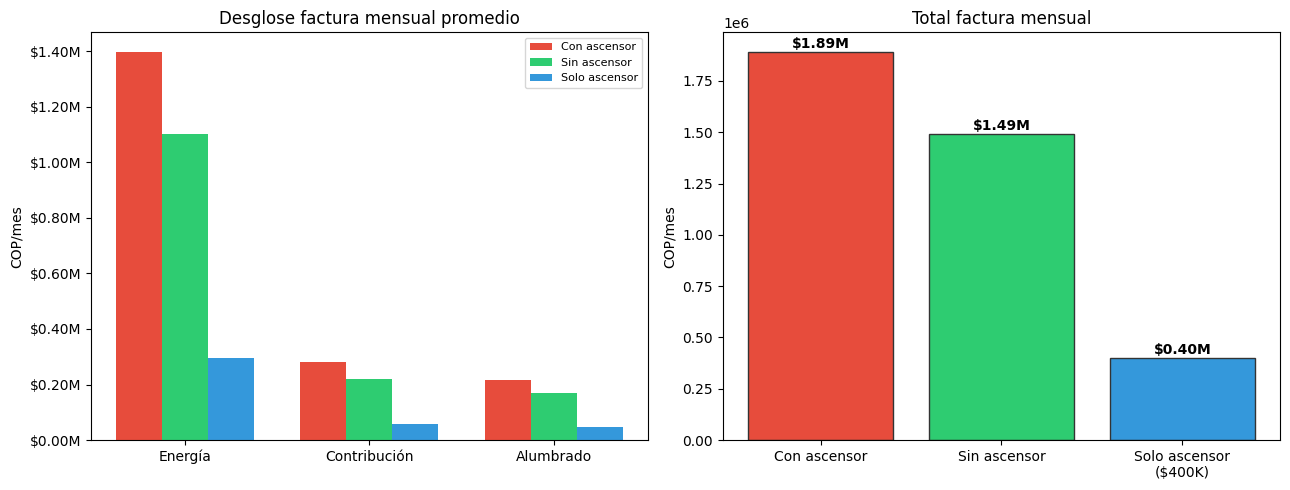

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: desglose factura mensual
conceptos = ["Energía", "Contribución", "Alumbrado"]
con_asc = [fact_con_asc_mes["energia_cop"], fact_con_asc_mes["contribucion_cop"], fact_con_asc_mes["alumbrado_cop"]]
sin_asc = [fact_sin_asc_mes["energia_cop"], fact_sin_asc_mes["contribucion_cop"], fact_sin_asc_mes["alumbrado_cop"]]
solo_asc = [costo_ascensor_mes["energia_cop"], costo_ascensor_mes["contribucion_cop"], costo_ascensor_mes["alumbrado_cop"]]
totales = [fact_con_asc_mes["total_cop"], fact_sin_asc_mes["total_cop"], COSTO_ASCENSOR_MES_REAL]

x = range(len(conceptos))
w = 0.25
ax1 = axes[0]
ax1.bar([i - w for i in x], con_asc, width=w, label="Con ascensor", color="#e74c3c")
ax1.bar(x, sin_asc, width=w, label="Sin ascensor", color="#2ecc71")
ax1.bar([i + w for i in x], solo_asc, width=w, label="Solo ascensor", color="#3498db")
ax1.set_xticks(x)
ax1.set_xticklabels(conceptos)
ax1.set_ylabel("COP/mes")
ax1.set_title("Desglose factura mensual promedio")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(lambda x, _: f"${x/1e6:.2f}M")

# Gráfico 2: total mensual
ax2 = axes[1]
totales = [fact_con_asc_mes["total_cop"], fact_sin_asc_mes["total_cop"], COSTO_ASCENSOR_MES_REAL]
labels = ["Con ascensor", "Sin ascensor", "Solo ascensor\n($400K)"]
colores = ["#e74c3c", "#2ecc71", "#3498db"]
bars = ax2.bar(labels, totales, color=colores, edgecolor="#333")
ax2.set_ylabel("COP/mes")
ax2.set_title("Total factura mensual")
for bar, val in zip(bars, totales):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
             f"${val/1e6:.2f}M", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

---
## Etapa 2 — Dimensionamiento factura cero + equipos Huawei

Objetivo: factura **$0** incluyendo alumbrado público, con margen para cargas futuras y suba de tarifa.

**Equipos:** paneles **710 Wp** + inversor **Huawei SUN2000-8/10K-LC0**

In [22]:
# ══════════════════════════════════════════════════════════════
# PARÁMETROS DE DISEÑO
# ══════════════════════════════════════════════════════════════
FACTOR_NUEVA_CARGA   = 1.10
FACTOR_SUBA_TARIFA   = 1.05
MARGEN_SEGURIDAD     = 1.10
FACTOR_FACTURA_TOTAL = COSTO_TOTAL_POR_KWH / CUV
HSP_estimado = 4.8
PR = 0.80
modulo_wp = 710

def dimensionar(consumo_anual_kwh, HSP, potencia_wp, PR=0.80):
    ppico_kw = consumo_anual_kwh / (HSP * 365 * PR)
    n_modulos = math.ceil(ppico_kw * 1000 / potencia_wp)
    return {
        "potencia_pico_kw": round(ppico_kw, 2),
        "n_modulos": n_modulos,
        "potencia_real_kwp": round(n_modulos * potencia_wp / 1000, 2),
    }

# Consumo base de diseño: sin ascensor + margen cargas
kwh_consumo_proyectado = consumo_anual_diseno * FACTOR_NUEVA_CARGA

kwh_generar_factura_cero = (
    kwh_consumo_proyectado
    * FACTOR_FACTURA_TOTAL
    * FACTOR_SUBA_TARIFA
    * MARGEN_SEGURIDAD
)

dim = dimensionar(kwh_generar_factura_cero, HSP_estimado, modulo_wp, PR)
produccion_anual = dim["potencia_real_kwp"] * HSP_estimado * 365 * PR
fact_mes_proyectada = calcular_factura(kwh_consumo_proyectado / 12)["total_cop"] * FACTOR_SUBA_TARIFA

print("=" * 60)
print("DIMENSIONAMIENTO FACTURA CERO — DIV 3 TABAREC")
print("=" * 60)
print(f"\nConsumo recibo (con ascensor):  {consumo_anual_recibo:,.0f} kWh/año")
print(f"Consumo diseño (sin ascensor):  {consumo_anual_diseno:,.0f} kWh/año")
print(f"Consumo proyectado (+10% carga): {kwh_consumo_proyectado:,.0f} kWh/año")
print(f"Generación objetivo:            {kwh_generar_factura_cero:,.0f} kWh/año")
print(f"\nSistema: {dim['n_modulos']} × {modulo_wp} Wp = {dim['potencia_real_kwp']} kWp")
print(f"Producción estimada:            {produccion_anual:,.0f} kWh/año")
print(f"\nFactura sin SFV (proyectada):    ${fact_mes_proyectada:,.0f} COP/mes")
print(f"Ahorro anual estimado:           ${fact_mes_proyectada * 12:,.0f} COP/año")
print("=" * 60)

DIMENSIONAMIENTO FACTURA CERO — DIV 3 TABAREC

Consumo recibo (con ascensor):  18,977 kWh/año
Consumo diseño (sin ascensor):  14,966 kWh/año
Consumo proyectado (+10% carga): 16,462 kWh/año
Generación objetivo:            25,742 kWh/año

Sistema: 26 × 710 Wp = 18.46 kWp
Producción estimada:            25,874 kWh/año

Factura sin SFV (proyectada):    $1,723,356 COP/mes
Ahorro anual estimado:           $20,680,267 COP/año


In [10]:
# ══════════════════════════════════════════════════════════════
# EQUIPOS — Huawei SUN2000 + paneles 710 Wp
# ══════════════════════════════════════════════════════════════
panel = {
    "potencia_wp": 710,
    "voc": 46.66, "vmp": 39.22,
    "isc": 19.24, "imp": 18.11,
    "coef_voc": 0.0025, "coef_vmp": -0.004,
    "area_m2": 2.38 * 1.30,
}

inversor_8k = {"modelo": "SUN2000-8K-LC0",  "potencia_ac_w": 8000,  "pv_max_wp": 12000, "mppt_count": 3,
               "mppt_v_min": 40, "mppt_v_max": 560, "voc_max": 600, "icc_max_mppt": 16}
inversor_10k = {"modelo": "SUN2000-10K-LC0", "potencia_ac_w": 10000, "pv_max_wp": 15000, "mppt_count": 3,
                "mppt_v_min": 40, "mppt_v_max": 560, "voc_max": 600, "icc_max_mppt": 16}

n_modulos = dim["n_modulos"]
potencia_dc_wp = n_modulos * modulo_wp

# Determinar cantidad de inversores
n_inversores_10k = math.ceil(potencia_dc_wp / inversor_10k["pv_max_wp"])
paneles_por_inversor = math.ceil(n_modulos / n_inversores_10k)
wp_por_inversor = paneles_por_inversor * modulo_wp

def verificar_string(n_paneles, inv):
    voc_frio = n_paneles * panel["voc"] * (1 + panel["coef_voc"] * 35)
    vmp_caliente = n_paneles * panel["vmp"] * (1 + panel["coef_vmp"] * 35)
    return {
        "voc_frio_v": round(voc_frio, 0),
        "vmp_caliente_v": round(vmp_caliente, 0),
        "ok": voc_frio <= inv["voc_max"] and vmp_caliente >= inv["mppt_v_min"],
        "ok_corriente": panel["imp"] <= inv["icc_max_mppt"],
    }

def disenar_strings(n_total, n_mppt=3):
    base, resto = divmod(n_total, n_mppt)
    return [base + 1] * resto + [base] * (n_mppt - resto)

strings = disenar_strings(paneles_por_inversor)
verif = [verificar_string(n, inversor_10k) for n in strings]

print("=" * 60)
print("CONFIGURACIÓN DE EQUIPOS")
print("=" * 60)
print(f"\nPaneles:      {n_modulos} × {modulo_wp} Wp = {potencia_dc_wp/1000:.2f} kWp")
print(f"Área total:   {n_modulos * panel['area_m2']:.0f} m²")
print(f"\nInversores:   {n_inversores_10k} × {inversor_10k['modelo']}")
print(f"              {paneles_por_inversor} paneles / inversor = {wp_por_inversor/1000:.2f} kWp DC c/u")
print(f"              Ratio DC/AC por inversor: {wp_por_inversor/inversor_10k['potencia_ac_w']:.2f}")
print(f"\nStrings (por inversor): {' + '.join(map(str, strings))} paneles en serie por MPPT")
for i, (n, v) in enumerate(zip(strings, verif), 1):
    print(f"  MPPT {i}: {n} pan. | Voc frío={v['voc_frio_v']}V | Vmp caliente={v['vmp_caliente_v']}V | "
          f"Imp={'OK' if v['ok_corriente'] else '→ OPTIMIZADOR'}")

if not all(v["ok_corriente"] for v in verif):
    print(f"\n⚠️  {n_modulos} × optimizador SUN2000-450W-P2 (Imp {panel['imp']} A > 16 A/MPPT)")
print("=" * 60)

CONFIGURACIÓN DE EQUIPOS

Paneles:      30 × 710 Wp = 21.30 kWp
Área total:   93 m²

Inversores:   2 × SUN2000-10K-LC0
              15 paneles / inversor = 10.65 kWp DC c/u
              Ratio DC/AC por inversor: 1.06

Strings (por inversor): 5 + 5 + 5 paneles en serie por MPPT
  MPPT 1: 5 pan. | Voc frío=254.0V | Vmp caliente=169.0V | Imp=→ OPTIMIZADOR
  MPPT 2: 5 pan. | Voc frío=254.0V | Vmp caliente=169.0V | Imp=→ OPTIMIZADOR
  MPPT 3: 5 pan. | Voc frío=254.0V | Vmp caliente=169.0V | Imp=→ OPTIMIZADOR

⚠️  30 × optimizador SUN2000-450W-P2 (Imp 18.11 A > 16 A/MPPT)


### Propuesta final — Div 3 TABAREC

| Ítem | Especificación |
|------|----------------|
| **Medidor** | HOL-100504639 |
| **Consumo diseño** | ~1 247 kWh/mes (sin ascensor) |
| **Ascensor** | ~$400 000 COP/mes (~334 kWh equiv.) |
| **Paneles** | **30 × 710 Wp = 21,3 kWp** |
| **Inversores** | **2 × Huawei SUN2000-10K-LC0** (15 pan. c/u) |
| **Optimizadores** | **30 × SUN2000-450W-P2** |
| **Producción est.** | ~29 850 kWh/año |
| **Objetivo** | Factura $0 incluyendo alumbrado público |

### Comparación con proyecto zonas comunes

| | Zonas comunes | Div 3 |
|--|--------------|-------|
| Consumo base | 375 kWh/mes | 1 581 kWh/mes |
| Ajuste ascensor | **+** 176 kWh/mes | **−** ~334 kWh/mes ($400K) |
| Consumo diseño | 551 kWh/mes | **~1 247 kWh/mes** |
| Medidor | HEX-16536166 | HOL-100504639 |
| Factura actual | ~$439 K | ~$1,89 M COP |
| SFV factura cero | 12 × 710 Wp (8K) | **30 × 710 Wp (2×10K)** |

---
## Alternativa: 2 × SUN2000-8K-LC0 en lugar de 2 × 10K

¿Se puede? **Sí, eléctricamente.** Pero hay **recorte (clipping)** y puede **no alcanzar** la factura cero con 30 paneles.

In [12]:
def estimar_clipping(ratio_dc_ac):
    """Pérdida anual estimada por recorte AC (ratio = Wp DC / W AC)."""
    if ratio_dc_ac <= 1.10:
        return 0.02
    if ratio_dc_ac <= 1.20:
        return 0.06
    if ratio_dc_ac <= 1.35:
        return 0.10
    return 0.14

def analizar_config(nombre, n_inversores, inv, n_paneles_total):
    max_pan_inv = inv["pv_max_wp"] // modulo_wp
    pan_inv = math.ceil(n_paneles_total / n_inversores)
    if pan_inv > max_pan_inv:
        return None
    wp_inv = pan_inv * modulo_wp
    wp_total = n_paneles_total * modulo_wp
    ratio = wp_inv / inv["potencia_ac_w"]
    clip = estimar_clipping(ratio)
    prod_bruta = wp_total / 1000 * HSP_estimado * 365 * PR
    prod_neta = prod_bruta * (1 - clip)
    return {
        "config": nombre,
        "inversores": f"{n_inversores} × {inv['modelo']}",
        "paneles": n_paneles_total,
        "kwp": wp_total / 1000,
        "pan_por_inv": pan_inv,
        "ratio_dc_ac": round(ratio, 2),
        "clip_pct": round(clip * 100, 0),
        "prod_kwh": round(prod_neta, 0),
        "cubre_objetivo": prod_neta >= kwh_generar_factura_cero,
        "deficit_kwh": round(max(0, kwh_generar_factura_cero - prod_neta), 0),
    }

configs = [
    analizar_config("2 × 10K — 30 pan.", 2, inversor_10k, 30),
    analizar_config("2 × 8K — 30 pan.",  2, inversor_8k,  30),
    analizar_config("2 × 8K — 32 pan.",  2, inversor_8k,  32),
    analizar_config("3 × 8K — 33 pan.",  3, inversor_8k,  33),
]

df_inv = pd.DataFrame([c for c in configs if c])
df_inv["factura_residual_mes"] = df_inv["deficit_kwh"].apply(
    lambda d: calcular_factura(d / 12)["total_cop"] * FACTOR_SUBA_TARIFA if d > 0 else 0
)

print("COMPARACIÓN DE INVERSORES\n")
cols = ["config", "paneles", "kwp", "ratio_dc_ac", "clip_pct", "prod_kwh", "cubre_objetivo", "factura_residual_mes"]
print(df_inv[cols].to_string(index=False))

print(f"\nGeneración objetivo (factura cero): {kwh_generar_factura_cero:,.0f} kWh/año")
print("\n--- Conclusión 2 × 8K con 30 paneles ---")
c_8k_30 = df_inv[df_inv["config"].str.contains("8K — 30")].iloc[0]
print(f"  Ratio DC/AC:      {c_8k_30['ratio_dc_ac']:.2f}  (ideal < 1,15)")
print(f"  Recorte estimado: {c_8k_30['clip_pct']:.0f} %")
print(f"  Producción:       {c_8k_30['prod_kwh']:,.0f} kWh/año  (faltan {c_8k_30['deficit_kwh']:,.0f})")
print(f"  Factura residual: ~${c_8k_30['factura_residual_mes']:,.0f} COP/mes")

COMPARACIÓN DE INVERSORES

           config  paneles   kwp  ratio_dc_ac  clip_pct  prod_kwh  cubre_objetivo  factura_residual_mes
2 × 10K — 30 pan.       30 21.30         1.06       2.0   29257.0            True                  0.00
 2 × 8K — 30 pan.       30 21.30         1.33      10.0   26869.0           False             223400.10
 2 × 8K — 32 pan.       32 22.72         1.42      14.0   27386.0           False             169277.85
 3 × 8K — 33 pan.       33 23.43         0.98       2.0   32183.0            True                  0.00

Generación objetivo (factura cero): 29,003 kWh/año

--- Conclusión 2 × 8K con 30 paneles ---
  Ratio DC/AC:      1.33  (ideal < 1,15)
  Recorte estimado: 10 %
  Producción:       26,869 kWh/año  (faltan 2,134)
  Factura residual: ~$223,400 COP/mes


---
## Bitácora

| Fecha | Decisión | Fuente |
|-------|----------|--------|
| 2026-06-22 | Nuevo proyecto Div 3 — recibo CEDENAR Feb/2026 | Recibo HOL-100504639 |
| 2026-06-22 | Ascensor: costo real ~$400 000 COP/mes (334 kWh equiv.) | Dato usuario |
| 2026-06-22 | Equipos: Huawei SUN2000-10K-LC0 + paneles 710 Wp | Ficha técnica Huawei |